In [41]:
import pandas as pd 
import sqlite3
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
import polty.express as px

ModuleNotFoundError: No module named 'polty'

In [2]:
con = sqlite3.connect(r"C:\Users\jhata\Downloads\Resources\zomato_rawdata.sqlite")

In [11]:
df = pd.read_sql_query("Select * from Users", con)

In [13]:
## Checking missing values 

df.isnull().sum()

index                              0
url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                            7775
votes                              0
phone                           1208
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)      346
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

In [15]:
df.isnull().sum()/len(df)*100

index                           0.000000
url                             0.000000
address                         0.000000
name                            0.000000
online_order                    0.000000
book_table                      0.000000
rate                           15.033741
votes                           0.000000
phone                           2.335789
location                        0.040606
rest_type                       0.438927
dish_liked                     54.291626
cuisines                        0.087012
approx_cost(for two people)     0.669026
reviews_list                    0.000000
menu_item                       0.000000
listed_in(type)                 0.000000
listed_in(city)                 0.000000
dtype: float64

In [17]:
df['rate'].unique()

array(['4.1/5', '3.8/5', '3.7/5', '3.6/5', '4.6/5', '4.0/5', '4.2/5',
       '3.9/5', '3.1/5', '3.0/5', '3.2/5', '3.3/5', '2.8/5', '4.4/5',
       '4.3/5', 'NEW', '2.9/5', '3.5/5', None, '2.6/5', '3.8 /5', '3.4/5',
       '4.5/5', '2.5/5', '2.7/5', '4.7/5', '2.4/5', '2.2/5', '2.3/5',
       '3.4 /5', '-', '3.6 /5', '4.8/5', '3.9 /5', '4.2 /5', '4.0 /5',
       '4.1 /5', '3.7 /5', '3.1 /5', '2.9 /5', '3.3 /5', '2.8 /5',
       '3.5 /5', '2.7 /5', '2.5 /5', '3.2 /5', '2.6 /5', '4.5 /5',
       '4.3 /5', '4.4 /5', '4.9/5', '2.1/5', '2.0/5', '1.8/5', '4.6 /5',
       '4.9 /5', '3.0 /5', '4.8 /5', '2.3 /5', '4.7 /5', '2.4 /5',
       '2.1 /5', '2.2 /5', '2.0 /5', '1.8 /5'], dtype=object)

In [19]:
df['rate'].replace(('NEW','-'), np.nan, inplace=True)

In [20]:
df['rate'].unique()

array(['4.1/5', '3.8/5', '3.7/5', '3.6/5', '4.6/5', '4.0/5', '4.2/5',
       '3.9/5', '3.1/5', '3.0/5', '3.2/5', '3.3/5', '2.8/5', '4.4/5',
       '4.3/5', nan, '2.9/5', '3.5/5', None, '2.6/5', '3.8 /5', '3.4/5',
       '4.5/5', '2.5/5', '2.7/5', '4.7/5', '2.4/5', '2.2/5', '2.3/5',
       '3.4 /5', '3.6 /5', '4.8/5', '3.9 /5', '4.2 /5', '4.0 /5',
       '4.1 /5', '3.7 /5', '3.1 /5', '2.9 /5', '3.3 /5', '2.8 /5',
       '3.5 /5', '2.7 /5', '2.5 /5', '3.2 /5', '2.6 /5', '4.5 /5',
       '4.3 /5', '4.4 /5', '4.9/5', '2.1/5', '2.0/5', '1.8/5', '4.6 /5',
       '4.9 /5', '3.0 /5', '4.8 /5', '2.3 /5', '4.7 /5', '2.4 /5',
       '2.1 /5', '2.2 /5', '2.0 /5', '1.8 /5'], dtype=object)

In [21]:
'4.1/5'.split('/')[0]

'4.1'

In [22]:
float('4.1/5'.split('/')[0])

4.1

In [23]:
type('4.1/5'.split('/')[0])

str

In [25]:
df['rate'] = df['rate'].apply(lambda x: float(x.split('/')[0]) if type(x)==str else x)

In [26]:
## Analysing relation relation between online order and rating

In [37]:
x = pd.crosstab(df['rate'], df['online_order'])

In [38]:
x

online_order,No,Yes
rate,,
1.8,5,0
2.0,11,0
2.1,9,15
2.2,10,16
2.3,29,22
2.4,36,34
2.5,38,63
2.6,83,177
2.7,141,166


<Axes: xlabel='rate'>

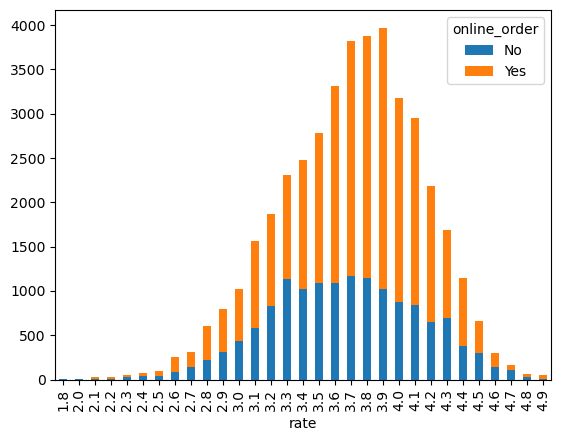

In [30]:
x.plot(kind='bar', stacked=True)

In [33]:
x.sum(axis=1).astype(float)

rate
1.8       5.0
2.0      11.0
2.1      24.0
2.2      26.0
2.3      51.0
2.4      70.0
2.5     101.0
2.6     260.0
2.7     307.0
2.8     600.0
2.9     802.0
3.0    1023.0
3.1    1561.0
3.2    1873.0
3.3    2310.0
3.4    2476.0
3.5    2784.0
3.6    3316.0
3.7    3821.0
3.8    3873.0
3.9    3972.0
4.0    3183.0
4.1    2948.0
4.2    2184.0
4.3    1693.0
4.4    1147.0
4.5     656.0
4.6     300.0
4.7     167.0
4.8      66.0
4.9      55.0
dtype: float64

In [35]:
normalize_df = x.div(x.sum(axis=1).astype(float), axis=0)

<Axes: xlabel='rate'>

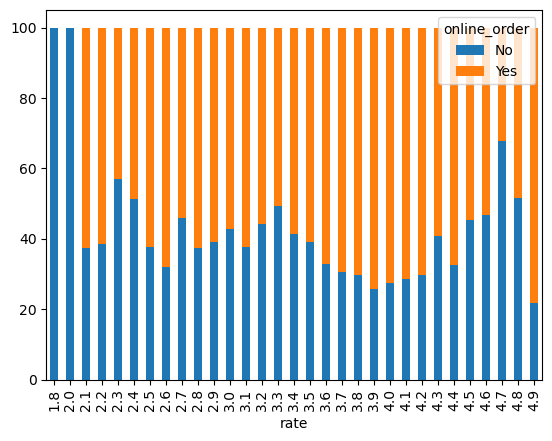

In [36]:
(normalize_df*100).plot(kind='bar', stacked=True)

In [42]:
## how to do text cleaning 

In [43]:
df['rest_type'].isnull().sum()

227

In [44]:
data=df.dropna(subset=['rest_type'])

In [45]:
data['rest_type'].isnull().sum()

0

In [46]:
data['rest_type'].unique()

array(['Casual Dining', 'Cafe, Casual Dining', 'Quick Bites',
       'Casual Dining, Cafe', 'Cafe', 'Quick Bites, Cafe',
       'Cafe, Quick Bites', 'Delivery', 'Mess', 'Dessert Parlor',
       'Bakery, Dessert Parlor', 'Pub', 'Bakery', 'Takeaway, Delivery',
       'Fine Dining', 'Beverage Shop', 'Sweet Shop', 'Bar',
       'Beverage Shop, Quick Bites', 'Confectionery',
       'Quick Bites, Beverage Shop', 'Dessert Parlor, Sweet Shop',
       'Bakery, Quick Bites', 'Sweet Shop, Quick Bites', 'Kiosk',
       'Food Truck', 'Quick Bites, Dessert Parlor',
       'Beverage Shop, Dessert Parlor', 'Takeaway', 'Pub, Casual Dining',
       'Casual Dining, Bar', 'Dessert Parlor, Beverage Shop',
       'Quick Bites, Bakery', 'Dessert Parlor, Quick Bites',
       'Microbrewery, Casual Dining', 'Lounge', 'Bar, Casual Dining',
       'Food Court', 'Cafe, Bakery', 'Dhaba', 'Quick Bites, Sweet Shop',
       'Microbrewery', 'Food Court, Quick Bites', 'Pub, Bar',
       'Casual Dining, Pub', 'Lounge, Ba

In [48]:
quick_bites_df=data[data['rest_type'].str.contains("Quick Bites")]

In [49]:
quick_bites_df.shape

(20639, 18)

In [50]:
quick_bites_df.columns

Index(['index', 'url', 'address', 'name', 'online_order', 'book_table', 'rate',
       'votes', 'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)'],
      dtype='object')

In [51]:
quick_bites_df['reviews_list']

3        [('Rated 4.0', "RATED\n  Great food and proper...
23       [('Rated 4.0', "RATED\n  So, went here with fr...
26       [('Rated 5.0', 'RATED\n  please provide some e...
31       [('Rated 1.0', "RATED\n  Worst restaurant ever...
34       [('Rated 3.0', 'RATED\n  Not worth for the mon...
                               ...                        
51641    [('Rated 2.0', "RATED\n  Food is not upto the ...
51642                                                   []
51643                                                   []
51644                                                   []
51645    [('Rated 5.0', "RATED\n  I was randomly lookin...
Name: reviews_list, Length: 20639, dtype: object

In [57]:
quick_bites_df['reviews_list'] = quick_bites_df['reviews_list'].apply(lambda x:x.lower())

C:\Users\jhata\AppData\Local\Temp\ipykernel_9404\4206969916.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  quick_bites_df['reviews_list'] = quick_bites_df['reviews_list'].apply(lambda x:x.lower())


In [58]:
from nltk.corpus import RegexpTokenizer

In [59]:
tokenzier= RegexpTokenizer("[a-zA-Z]+")

In [62]:
tokenzier

RegexpTokenizer(pattern='[a-zA-Z]+', gaps=False, discard_empty=True, flags=re.UNICODE|re.MULTILINE|re.DOTALL)

In [63]:
tokenzier.tokenize(quick_bites_df['reviews_list'][3])

['rated',
 'rated',
 'n',
 'great',
 'food',
 'and',
 'proper',
 'karnataka',
 'style',
 'full',
 'meals',
 'been',
 'there',
 'twice',
 'and',
 'was',
 'fully',
 'satisfied',
 'will',
 'give',
 'stars',
 'if',
 'it',
 's',
 'well',
 'managed',
 'rated',
 'rated',
 'n',
 'reached',
 'the',
 'place',
 'at',
 'pm',
 'on',
 'saturday',
 'half',
 'of',
 'the',
 'items',
 'on',
 'the',
 'menu',
 'were',
 'over',
 'what',
 'was',
 'annoying',
 'was',
 'is',
 'the',
 'food',
 'was',
 'cold',
 'the',
 'taste',
 'was',
 'also',
 'very',
 'average',
 'only',
 'dosa',
 'and',
 'holige',
 'were',
 'good',
 'there',
 'were',
 'very',
 'few',
 'people',
 'in',
 'the',
 'restaurant',
 'and',
 'the',
 'service',
 'was',
 'still',
 'very',
 'slow',
 'the',
 'waiters',
 'were',
 'all',
 'standing',
 'in',
 'one',
 'corner',
 'and',
 'talking',
 'had',
 'to',
 'call',
 'them',
 'repeatedly',
 'rated',
 'rated',
 'n',
 'had',
 'been',
 'here',
 'good',
 'food',
 'served',
 'and',
 'tasty',
 'good',
 'plac

In [64]:
sample = data[0:10000]

In [65]:
reviews_tokens = sample['reviews_list'].apply(tokenzier.tokenize)

In [66]:
reviews_tokens

0        [Rated, RATED, n, A, beautiful, place, to, din...
1        [Rated, RATED, n, Had, been, here, for, dinner...
2        [Rated, RATED, n, Ambience, is, not, that, goo...
3        [Rated, RATED, n, Great, food, and, proper, Ka...
4        [Rated, RATED, n, Very, good, restaurant, in, ...
                               ...                        
10046    [Rated, RATED, n, A, simplistic, joy, for, loc...
10047                              [Rated, RATED, n, Good]
10048    [Rated, RATED, n, Vry, gud, taste, and, someth...
10049                                                   []
10050                                                   []
Name: reviews_list, Length: 10000, dtype: object

In [68]:
## UniGram Analysis  and removal of stopwords.

In [69]:
reviews_tokens

0        [Rated, RATED, n, A, beautiful, place, to, din...
1        [Rated, RATED, n, Had, been, here, for, dinner...
2        [Rated, RATED, n, Ambience, is, not, that, goo...
3        [Rated, RATED, n, Great, food, and, proper, Ka...
4        [Rated, RATED, n, Very, good, restaurant, in, ...
                               ...                        
10046    [Rated, RATED, n, A, simplistic, joy, for, loc...
10047                              [Rated, RATED, n, Good]
10048    [Rated, RATED, n, Vry, gud, taste, and, someth...
10049                                                   []
10050                                                   []
Name: reviews_list, Length: 10000, dtype: object

In [74]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jhata\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [75]:
from nltk.corpus import stopwords
stop = stopwords.words('english')

In [77]:
stop.extend(['rated','n','nan','x','RATED','Rated'])

In [78]:
 reviews_tokens

0        [Rated, RATED, n, A, beautiful, place, to, din...
1        [Rated, RATED, n, Had, been, here, for, dinner...
2        [Rated, RATED, n, Ambience, is, not, that, goo...
3        [Rated, RATED, n, Great, food, and, proper, Ka...
4        [Rated, RATED, n, Very, good, restaurant, in, ...
                               ...                        
10046    [Rated, RATED, n, A, simplistic, joy, for, loc...
10047                              [Rated, RATED, n, Good]
10048    [Rated, RATED, n, Vry, gud, taste, and, someth...
10049                                                   []
10050                                                   []
Name: reviews_list, Length: 10000, dtype: object

In [81]:
rev3 = reviews_tokens[3]
print(rev3)

['Rated', 'RATED', 'n', 'Great', 'food', 'and', 'proper', 'Karnataka', 'style', 'full', 'meals', 'Been', 'there', 'twice', 'and', 'was', 'fully', 'satisfied', 'Will', 'give', 'stars', 'if', 'it', 's', 'well', 'managed', 'Rated', 'RATED', 'n', 'Reached', 'the', 'place', 'at', 'pm', 'on', 'Saturday', 'Half', 'of', 'the', 'items', 'on', 'the', 'menu', 'were', 'over', 'What', 'was', 'annoying', 'was', 'is', 'the', 'food', 'was', 'cold', 'The', 'taste', 'was', 'also', 'very', 'average', 'Only', 'dosa', 'and', 'holige', 'were', 'good', 'There', 'were', 'very', 'few', 'people', 'in', 'the', 'restaurant', 'and', 'the', 'service', 'was', 'still', 'very', 'slow', 'The', 'waiters', 'were', 'all', 'standing', 'in', 'one', 'corner', 'and', 'talking', 'Had', 'to', 'call', 'them', 'repeatedly', 'Rated', 'RATED', 'n', 'Had', 'been', 'here', 'good', 'food', 'served', 'and', 'tasty', 'good', 'place', 'to', 'go', 'with', 'freinds', 'and', 'family', 'should', 'be', 'first', 'to', 'get', 'served', 'well', 

In [83]:
print([token for token in rev3 if token not in stop])

['Great', 'food', 'proper', 'Karnataka', 'style', 'full', 'meals', 'Been', 'twice', 'fully', 'satisfied', 'Will', 'give', 'stars', 'well', 'managed', 'Reached', 'place', 'pm', 'Saturday', 'Half', 'items', 'menu', 'What', 'annoying', 'food', 'cold', 'The', 'taste', 'also', 'average', 'Only', 'dosa', 'holige', 'good', 'There', 'people', 'restaurant', 'service', 'still', 'slow', 'The', 'waiters', 'standing', 'one', 'corner', 'talking', 'Had', 'call', 'repeatedly', 'Had', 'good', 'food', 'served', 'tasty', 'good', 'place', 'go', 'freinds', 'family', 'first', 'get', 'served', 'well', 'food', 'One', 'good', 'hotel', 'price', 'How', 'Udupi', 'restaurant', 'dirty', 'floor', 'walls', 'waiters', 'stained', 'food', 'Why', 'cant', 'clean', 'The', 'floor', 'even', 'decorative', 'colour', 'paper', 'every', 'lot', 'food', 'Now', 'coming', 'taste', 'food', 'pretty', 'decent', 'chargw', 'What', 'upset', 'us', 'menu', 'says', 'serve', 'thambuli', 'two', 'variety', 'rice', 'etc', 'still', 'charged', 'us'

In [85]:
reviews_tokens_clean = reviews_tokens.apply(lambda each_review :[token for token in rev3 if token not in stop])

In [86]:
reviews_tokens_clean 

0        [Great, food, proper, Karnataka, style, full, ...
1        [Great, food, proper, Karnataka, style, full, ...
2        [Great, food, proper, Karnataka, style, full, ...
3        [Great, food, proper, Karnataka, style, full, ...
4        [Great, food, proper, Karnataka, style, full, ...
                               ...                        
10046    [Great, food, proper, Karnataka, style, full, ...
10047    [Great, food, proper, Karnataka, style, full, ...
10048    [Great, food, proper, Karnataka, style, full, ...
10049    [Great, food, proper, Karnataka, style, full, ...
10050    [Great, food, proper, Karnataka, style, full, ...
Name: reviews_list, Length: 10000, dtype: object

In [87]:
type(reviews_tokens_clean)

pandas.core.series.Series

In [88]:
total = list(reviews_tokens_clean )

In [89]:
total_1d = []

for review in total:
    for word in review:
        total_1d.append(word)

In [91]:
total_1d

['Great',
 'food',
 'proper',
 'Karnataka',
 'style',
 'full',
 'meals',
 'Been',
 'twice',
 'fully',
 'satisfied',
 'Will',
 'give',
 'stars',
 'well',
 'managed',
 'Reached',
 'place',
 'pm',
 'Saturday',
 'Half',
 'items',
 'menu',
 'What',
 'annoying',
 'food',
 'cold',
 'The',
 'taste',
 'also',
 'average',
 'Only',
 'dosa',
 'holige',
 'good',
 'There',
 'people',
 'restaurant',
 'service',
 'still',
 'slow',
 'The',
 'waiters',
 'standing',
 'one',
 'corner',
 'talking',
 'Had',
 'call',
 'repeatedly',
 'Had',
 'good',
 'food',
 'served',
 'tasty',
 'good',
 'place',
 'go',
 'freinds',
 'family',
 'first',
 'get',
 'served',
 'well',
 'food',
 'One',
 'good',
 'hotel',
 'price',
 'How',
 'Udupi',
 'restaurant',
 'dirty',
 'floor',
 'walls',
 'waiters',
 'stained',
 'food',
 'Why',
 'cant',
 'clean',
 'The',
 'floor',
 'even',
 'decorative',
 'colour',
 'paper',
 'every',
 'lot',
 'food',
 'Now',
 'coming',
 'taste',
 'food',
 'pretty',
 'decent',
 'chargw',
 'What',
 'upset',
 '

In [92]:
from nltk import FreqDist

In [93]:
fd = FreqDist()

In [94]:
for word in total_1d:
    fd[word] = fd[word] + 1

In [95]:
fd.most_common(20)

[('I', 670000),
 ('food', 590000),
 ('south', 270000),
 ('Indian', 230000),
 ('place', 210000),
 ('good', 210000),
 ('taste', 200000),
 ('served', 170000),
 ('The', 150000),
 ('variety', 130000),
 ('quality', 130000),
 ('still', 120000),
 ('There', 110000),
 ('people', 110000),
 ('meal', 110000),
 ('leaf', 110000),
 ('authentic', 100000),
 ('But', 100000),
 ('feel', 100000),
 ('much', 100000)]

<Axes: xlabel='Samples', ylabel='Counts'>

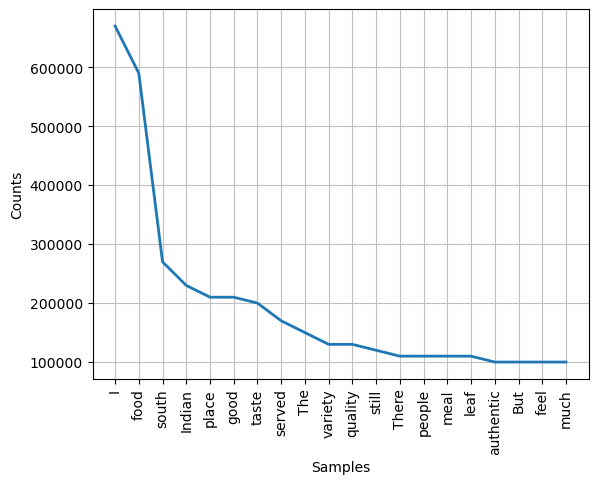

In [100]:
fd.plot(20)

In [97]:
## Perform Bi-Gram & Tri-gram analysis on data 

In [109]:
from nltk import FreqDist, bigrams, trigrams

bi_grams = bigrams(total_1d)

fd_bigrams = FreqDist()

for bigram in bi_grams:
    fd_bigrams[bigram] = fd_bigrams[bigram] + 1  

fd_bigrams.most_common(20)

[(('south', 'Indian'), 230000),
 (('Indian', 'food'), 180000),
 (('waiting', 'staffs'), 100000),
 (('authentic', 'south'), 90000),
 (('food', 'served'), 70000),
 (('value', 'money'), 60000),
 (('food', 'quality'), 60000),
 (('quality', 'taste'), 60000),
 (('food', 'I'), 60000),
 (('Food', 'good'), 60000),
 (('Been', 'last'), 50000),
 (('last', 'week'), 50000),
 (('week', 'high'), 50000),
 (('high', 'expectations'), 50000),
 (('expectations', 'based'), 50000),
 (('based', 'reviews'), 50000),
 (('reviews', 'But'), 50000),
 (('But', 'utterly'), 50000),
 (('utterly', 'disappointed'), 50000),
 (('disappointed', 'food'), 50000)]

<Axes: xlabel='Samples', ylabel='Counts'>

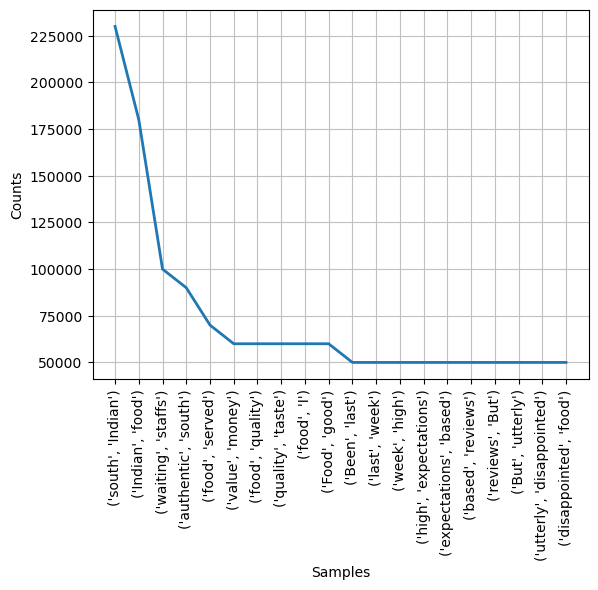

In [110]:
fd_bigrams.plot(20)

In [112]:
fd_bigrams.most_common(100)

[(('south', 'Indian'), 230000),
 (('Indian', 'food'), 180000),
 (('waiting', 'staffs'), 100000),
 (('authentic', 'south'), 90000),
 (('food', 'served'), 70000),
 (('value', 'money'), 60000),
 (('food', 'quality'), 60000),
 (('quality', 'taste'), 60000),
 (('food', 'I'), 60000),
 (('Food', 'good'), 60000),
 (('Been', 'last'), 50000),
 (('last', 'week'), 50000),
 (('week', 'high'), 50000),
 (('high', 'expectations'), 50000),
 (('expectations', 'based'), 50000),
 (('based', 'reviews'), 50000),
 (('reviews', 'But'), 50000),
 (('But', 'utterly'), 50000),
 (('utterly', 'disappointed'), 50000),
 (('disappointed', 'food'), 50000),
 (('taste', 'I'), 50000),
 (('I', 'feel'), 50000),
 (('feel', 'overhyped'), 50000),
 (('overhyped', 'place'), 50000),
 (('place', 'There'), 50000),
 (('There', 'many'), 50000),
 (('many', 'better'), 50000),
 (('better', 'places'), 50000),
 (('places', 'vicinity'), 50000),
 (('vicinity', 'Plantain'), 50000),
 (('Plantain', 'leaf'), 50000),
 (('leaf', 'meal'), 50000),


In [113]:
tri_grams = trigrams(total_1d)

In [115]:
tri_grams = FreqDist()

for trigram in tri_grams:
    fd_trigrams[bigram] = fd_trigrams[trigram] + 1  

fd_bigrams.most_common(50)

[(('south', 'Indian'), 230000),
 (('Indian', 'food'), 180000),
 (('waiting', 'staffs'), 100000),
 (('authentic', 'south'), 90000),
 (('food', 'served'), 70000),
 (('value', 'money'), 60000),
 (('food', 'quality'), 60000),
 (('quality', 'taste'), 60000),
 (('food', 'I'), 60000),
 (('Food', 'good'), 60000),
 (('Been', 'last'), 50000),
 (('last', 'week'), 50000),
 (('week', 'high'), 50000),
 (('high', 'expectations'), 50000),
 (('expectations', 'based'), 50000),
 (('based', 'reviews'), 50000),
 (('reviews', 'But'), 50000),
 (('But', 'utterly'), 50000),
 (('utterly', 'disappointed'), 50000),
 (('disappointed', 'food'), 50000),
 (('taste', 'I'), 50000),
 (('I', 'feel'), 50000),
 (('feel', 'overhyped'), 50000),
 (('overhyped', 'place'), 50000),
 (('place', 'There'), 50000),
 (('There', 'many'), 50000),
 (('many', 'better'), 50000),
 (('better', 'places'), 50000),
 (('places', 'vicinity'), 50000),
 (('vicinity', 'Plantain'), 50000),
 (('Plantain', 'leaf'), 50000),
 (('leaf', 'meal'), 50000),


In [116]:
## Let's Extract geographical-coordinates from data 


In [117]:
df.head(3)

,index,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari


In [118]:
!pip install geocoder 
!pip install geopy

In [119]:
df['location']

0                      Banashankari
1                      Banashankari
2                      Banashankari
3                      Banashankari
4                      Basavanagudi
                    ...            
51712                    Whitefield
51713                    Whitefield
51714                    Whitefield
51715    ITPL Main Road, Whitefield
51716    ITPL Main Road, Whitefield
Name: location, Length: 51717, dtype: object

In [121]:
df['location'].unique()

array(['Banashankari', 'Basavanagudi', 'Mysore Road', 'Jayanagar',
       'Kumaraswamy Layout', 'Rajarajeshwari Nagar', 'Vijay Nagar',
       'Uttarahalli', 'JP Nagar', 'South Bangalore', 'City Market',
       'Nagarbhavi', 'Bannerghatta Road', 'BTM', 'Kanakapura Road',
       'Bommanahalli', None, 'CV Raman Nagar', 'Electronic City', 'HSR',
       'Marathahalli', 'Sarjapur Road', 'Wilson Garden', 'Shanti Nagar',
       'Koramangala 5th Block', 'Koramangala 8th Block', 'Richmond Road',
       'Koramangala 7th Block', 'Jalahalli', 'Koramangala 4th Block',
       'Bellandur', 'Whitefield', 'East Bangalore', 'Old Airport Road',
       'Indiranagar', 'Koramangala 1st Block', 'Frazer Town', 'RT Nagar',
       'MG Road', 'Brigade Road', 'Lavelle Road', 'Church Street',
       'Ulsoor', 'Residency Road', 'Shivajinagar', 'Infantry Road',
       'St. Marks Road', 'Cunningham Road', 'Race Course Road',
       'Commercial Street', 'Vasanth Nagar', 'HBR Layout', 'Domlur',
       'Ejipura', 'Jeevan

In [122]:
len(df['location'].unique())

94

In [123]:
df['location'] = df['location']+ " , Bangalore , Karnataka, India"

In [124]:
df['location']

0              Banashankari , Bangalore , Karnataka, India
1              Banashankari , Bangalore , Karnataka, India
2              Banashankari , Bangalore , Karnataka, India
3              Banashankari , Bangalore , Karnataka, India
4              Basavanagudi , Bangalore , Karnataka, India
                               ...                        
51712            Whitefield , Bangalore , Karnataka, India
51713            Whitefield , Bangalore , Karnataka, India
51714            Whitefield , Bangalore , Karnataka, India
51715    ITPL Main Road, Whitefield , Bangalore , Karna...
51716    ITPL Main Road, Whitefield , Bangalore , Karna...
Name: location, Length: 51717, dtype: object

In [125]:
df['location'] .unique

<bound method Series.unique of 0              Banashankari , Bangalore , Karnataka, India
1              Banashankari , Bangalore , Karnataka, India
2              Banashankari , Bangalore , Karnataka, India
3              Banashankari , Bangalore , Karnataka, India
4              Basavanagudi , Bangalore , Karnataka, India
                               ...                        
51712            Whitefield , Bangalore , Karnataka, India
51713            Whitefield , Bangalore , Karnataka, India
51714            Whitefield , Bangalore , Karnataka, India
51715    ITPL Main Road, Whitefield , Bangalore , Karna...
51716    ITPL Main Road, Whitefield , Bangalore , Karna...
Name: location, Length: 51717, dtype: object>

In [126]:
df_copy = df.copy()

In [127]:
df_copy['location'].isnull().sum()

21

In [132]:
df_copy = df_copy.dropna(subset=['location'])

In [133]:
df_copy['location'].isnull().sum()

0

In [137]:
locations = pd.DataFrame(df['location'].unique())

In [139]:
locations.columns = ['name']

In [140]:
locations

,name
0,"Banashankari , Bangalore , Karnataka, India"
1,"Basavanagudi , Bangalore , Karnataka, India"
2,"Mysore Road , Bangalore , Karnataka, India"
3,"Jayanagar , Bangalore , Karnataka, India"
4,"Kumaraswamy Layout , Bangalore , Karnataka, India"
...,...
89,"West Bangalore , Bangalore , Karnataka, India"
90,"Magadi Road , Bangalore , Karnataka, India"
91,"Yelahanka , Bangalore , Karnataka, India"
92,"Sahakara Nagar , Bangalore , Karnataka, India"


In [141]:
from geopy.geocoders import Nominatim

In [142]:
geolocator = Nominatim(user_agent='app', timeout=None)

In [148]:
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import numpy as np

geolocator = Nominatim(user_agent="my_zomato_app_123")
geocode = RateLimiter(
    geolocator.geocode, 
    min_delay_seconds=2,        
    error_wait_seconds=10,      
    max_retries=3,             
    swallow_exceptions=True     
)

lat = []
lon = []

for name in locations['name']:
    loc = geocode(name)
    if loc is None:
        lat.append(np.nan)
        lon.append(np.nan)
    else:
        lat.append(loc.latitude)
        lon.append(loc.longitude)

locations['lat'] = lat
locations['lon'] = lon

RateLimiter caught an error, retrying (0/3 tries). Called with (*('Banashankari , Bangalore , Karnataka, India',), **{}).
Traceback (most recent call last):
  File "C:\Users\jhata\anaconda3\Lib\site-packages\urllib3\connectionpool.py", line 536, in _make_request
    response = conn.getresponse()
               ^^^^^^^^^^^^^^^^^^
  File "C:\Users\jhata\anaconda3\Lib\site-packages\urllib3\connection.py", line 507, in getresponse
    httplib_response = super().getresponse()
                       ^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\jhata\anaconda3\Lib\http\client.py", line 1428, in getresponse
    response.begin()
  File "C:\Users\jhata\anaconda3\Lib\http\client.py", line 331, in begin
    version, status, reason = self._read_status()
                              ^^^^^^^^^^^^^^^^^^^
  File "C:\Users\jhata\anaconda3\Lib\http\client.py", line 292, in _read_status
    line = str(self.fp.readline(_MAXLINE + 1), "iso-8859-1")
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\j

In [149]:
locations

,name,lat,lon
0,"Banashankari , Bangalore , Karnataka, India",12.927820,77.556621
1,"Basavanagudi , Bangalore , Karnataka, India",12.941726,77.575502
2,"Mysore Road , Bangalore , Karnataka, India",12.946662,77.530090
3,"Jayanagar , Bangalore , Karnataka, India",12.929273,77.582423
4,"Kumaraswamy Layout , Bangalore , Karnataka, India",12.915040,77.567888
...,...,...,...
89,"West Bangalore , Bangalore , Karnataka, India",13.022235,77.567183
90,"Magadi Road , Bangalore , Karnataka, India",12.975608,77.555356
91,"Yelahanka , Bangalore , Karnataka, India",13.100698,77.596345
92,"Sahakara Nagar , Bangalore , Karnataka, India",13.062147,77.580061


In [ ]:
## lets Perform Spatial analysis 

In [151]:
locations.isnull().sum()

name    1
lat     3
lon     3
dtype: int64

In [154]:
import warnings 
from warnings import filterwarnings 
filterwarnings('ignore')

locations[locations['lat'].isna()]

,name,lat,lon
65,"ITPL Main Road, Whitefield , Bangalore , Karna...",NaN,NaN
80,"Rammurthy Nagar , Bangalore , Karnataka, India",NaN,NaN
86,"Sadashiv Nagar , Bangalore , Karnataka, India",NaN,NaN


In [157]:
locations['lat'][65] = 12.967576
locations['lon'][65] = 77.7150877

In [158]:
locations[locations['lat'].isna()]

,name,lat,lon
80,"Rammurthy Nagar , Bangalore , Karnataka, India",NaN,NaN
86,"Sadashiv Nagar , Bangalore , Karnataka, India",NaN,NaN


In [160]:
locations['lat'][80] = 13.0163
locations['lon'][80] = 77.6785 

In [162]:
locations['lat'][86] = 13.0068
locations['lon'][86] = 77.5813

In [171]:
df['cuisines'].isnull().sum()

0

In [169]:
df = df.dropna(subset=['cuisines'])

In [172]:
north_india=df[df['cuisines'].str.contains("North Indian")]

In [175]:
north_india.shape

(21085, 18)

In [190]:
north_india_rest = north_india['location'].value_counts().reset_index() 
north_india_rest.columns = ['name', 'count']

In [192]:
heat_map = north_india_rest.merge(locations, on='name', how='left')

In [193]:
heat_map.head()

,name,count,lat,lon
0,"BTM , Bangalore , Karnataka, India",2469,12.911276,77.604565
1,"HSR , Bangalore , Karnataka, India",1123,12.911623,77.638862
2,"Whitefield , Bangalore , Karnataka, India",1059,12.996400,77.761423
3,"Marathahalli , Bangalore , Karnataka, India",1038,12.955257,77.698416
4,"JP Nagar , Bangalore , Karnataka, India",958,12.909694,77.586607


In [195]:
!pip install folium
import folium 

In [197]:
basemap = folium.Map()

In [198]:
basemap

In [199]:
from folium.plugins import HeatMap 

In [200]:
heat_map.columns

Index(['name', 'count', 'lat', 'lon'], dtype='object')

In [202]:
HeatMap(heat_map[['lat', 'lon','count']]).add_to(basemap)

In [203]:
basemap

In [204]:
## How to automate your data analysis 

In [209]:
def get_heatmap(cuisine):
    cuisine_df= df[df['cuisines'].str.contains(cuisine)] 

    cuisine_rest = cuisine_df['location'].value_counts().reset_index() 
    cuisine_rest.columns = ['name', 'count']
    heat_map = cuisine_rest.merge(locations, on='name', how='left')
    print(heat_map.head(4))

    basemap = folium.Map()
    HeatMap(heat_map[['lat','lon','count']]).add_to(basemap)
    return basemap 

In [210]:
get_heatmap("South Indian")

                                       name  count        lat        lon
0        BTM , Bangalore , Karnataka, India    815  12.911276  77.604565
1   JP Nagar , Bangalore , Karnataka, India    437  12.909694  77.586607
2        HSR , Bangalore , Karnataka, India    436  12.911623  77.638862
3  Jayanagar , Bangalore , Karnataka, India    416  12.929273  77.582423
